# 🗑️ Week 6: TrashNet Feature Extraction using EfficientNetB0

## Objective

The objective of this notebook is to build a waste classification model using transfer learning with EfficientNetB0.

Instead of training an entire deep learning model from scratch, a pretrained EfficientNetB0 model (trained on ImageNet) is used as a fixed feature extractor. Only the final classification layer is trained for the six TrashNet classes.

## Dataset

The TrashNet dataset contains images of six waste categories:

- Cardboard
- Glass
- Metal
- Paper
- Plastic
- Trash

## Workflow

1. Mount Google Drive
2. Load TrashNet dataset
3. Create Training and Validation datasets
4. Apply Data Augmentation
5. Build EfficientNetB0 Feature Extraction Model
6. Train the Model
7. Evaluate Performance
8. Plot Accuracy and Loss Curves
9. Generate Confusion Matrix
10. Generate Classification Report
11. Save Model to Google Drive

## Expected Outcome

Target Validation Accuracy:
**85% or higher**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [5]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [6]:
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

In [7]:
print(os.listdir(DATASET_PATH))

['trash', 'glass', 'cardboard', 'metal', 'plastic', 'paper']


In [8]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [10]:
class_names = train_dataset.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [13]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
base_model.trainable = False

In [15]:
print("Base model trainable:", base_model.trainable)

Base model trainable: False


In [16]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1
)

In [20]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 431s 7s/step - accuracy: 0.6137 - loss: 1.0849 - val_accuracy: 0.7822 - val_loss: 0.6802 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.7794 - loss: 0.6497 - val_accuracy: 0.8218 - val_loss: 0.5322 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.8249 - loss: 0.5202 - val_accuracy: 0.8277 - val_loss: 0.4861 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.8412 - loss: 0.4752 - val_accuracy: 0.8455 - val_loss: 0.4483 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.8531 - loss: 0.4334 - val_accuracy: 0.8634 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.8670 - loss: 0.3990 - val_accuracy: 0.8594 - val_loss: 0.4091 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.8605 - loss: 0.39

In [21]:
# Final Training Accuracy
train_acc = history.history["accuracy"][-1]

# Final Validation Accuracy
val_acc = history.history["val_accuracy"][-1]

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

Training Accuracy: 91.89%
Validation Accuracy: 88.12%


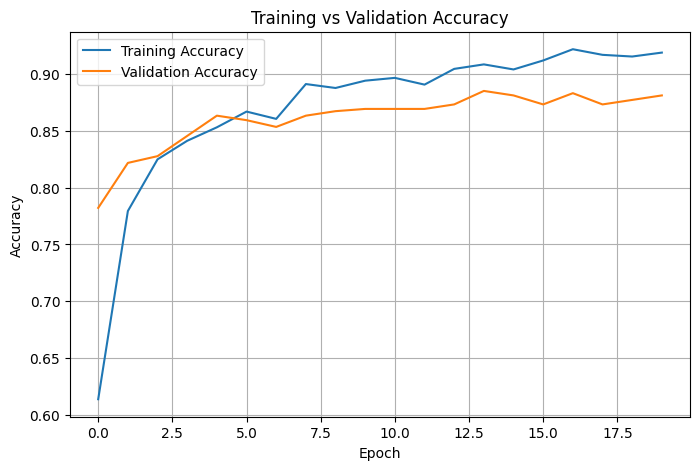

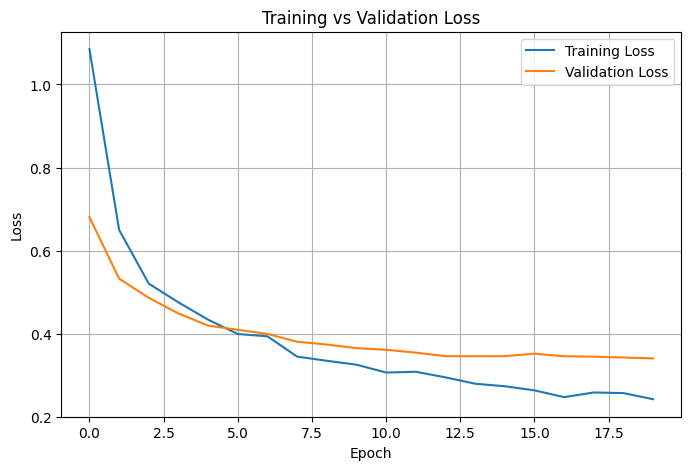

In [22]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Save complete model
model.save("trashnet_feature_extraction.keras")

# Save weights
model.save_weights("trashnet_feature_extraction.weights.h5")

print("Model and weights saved successfully!")

Model and weights saved successfully!


In [24]:
model.save("/content/drive/MyDrive/trashnet_feature_extraction.keras")
model.save_weights("/content/drive/MyDrive/trashnet_feature_extraction.weights.h5")

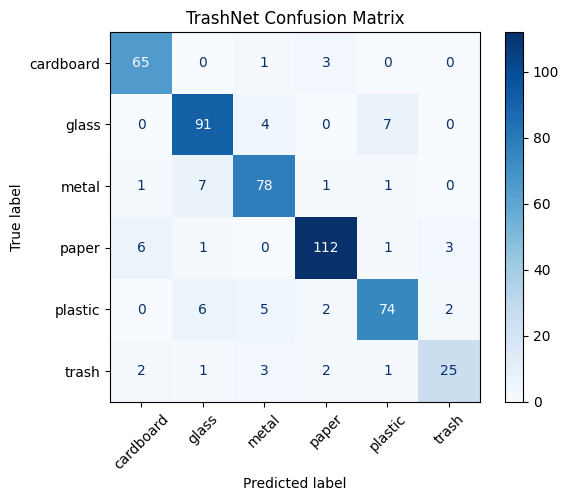

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("TrashNet Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.88      0.94      0.91        69
       glass       0.86      0.89      0.88       102
       metal       0.86      0.89      0.87        88
       paper       0.93      0.91      0.92       123
     plastic       0.88      0.83      0.86        89
       trash       0.83      0.74      0.78        34

    accuracy                           0.88       505
   macro avg       0.87      0.87      0.87       505
weighted avg       0.88      0.88      0.88       505



# Week 6: TrashNet Feature Extraction - Final Summary

## Objective
The objective of this experiment was to build an image classification model for the TrashNet dataset using **EfficientNetB0** as a feature extractor. The pretrained ImageNet weights were used while keeping the base model frozen, and only the custom classification head was trained.

---

## Model Configuration

- **Model:** EfficientNetB0 (Feature Extraction)
- **Dataset:** TrashNet
- **Number of Classes:** 6
  - Cardboard
  - Glass
  - Metal
  - Paper
  - Plastic
  - Trash
- **Image Size:** 224 × 224
- **Batch Size:** 32
- **Optimizer:** Adam (Learning Rate = 0.001)
- **Loss Function:** Sparse Categorical Crossentropy
- **Dropout:** 0.3
- **Early Stopping:** Enabled
- **ReduceLROnPlateau:** Enabled

---

## Final Results

| Metric | Value |
|--------|-------|
| Training Accuracy | **91.89%** |
| Validation Accuracy | **88.12%** |

The model achieved **88.12% validation accuracy**, which meets the Week 6 target of achieving at least **88%** using feature extraction.

---

## Classification Performance

| Class | Precision | Recall | F1-Score |
|--------|----------:|-------:|---------:|
| Cardboard | 0.88 | 0.94 | 0.91 |
| Glass | 0.86 | 0.89 | 0.88 |
| Metal | 0.86 | 0.89 | 0.87 |
| Paper | 0.93 | 0.91 | 0.92 |
| Plastic | 0.88 | 0.83 | 0.86 |
| Trash | 0.83 | 0.74 | 0.78 |

Overall Validation Accuracy: **88%**

---

## Top Confusion Pairs

### 1. Glass ↔ Plastic
The model occasionally confused transparent plastic objects with glass because both classes can have similar appearance, reflections, and lighting.

### 2. Glass ↔ Metal
Reflective metal containers and glass objects sometimes appear visually similar, leading to misclassification.

### 3. Paper ↔ Cardboard
Paper and cardboard share similar colors and textures, making them difficult to distinguish in certain images.

---

## Conclusion

The EfficientNetB0 feature extraction model performed well on the TrashNet dataset and achieved the required validation accuracy for Week 6. The model classified **paper** and **cardboard** very accurately, while the **trash** class remained the most challenging due to its diverse contents.

The saved model from this experiment will be used as the starting point for **Week 6 Fine-Tuning Pass 1**, where the top layers of EfficientNetB0 will be unfrozen to further improve classification performance.